# Lot D — Analyse quantitative et qualitative
**Projet ELOQUENT — Cultural Robustness & Diversity**

Ce notebook analyse les outputs du pipeline pour comparer :
- Les statistiques de base (longueur, réponses vides)
- La diversité et cohérence sémantique via embeddings
- La baseline vs les variantes de prompting
- Des exemples qualitatifs sélectionnés

## 0. Installation des dépendances

In [1]:
pip install sentence-transformers pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Chargement des données

In [2]:
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ── Configuration ──────────────────────────────────────────────────────────────
# Dossier contenant les fichiers JSONL de soumission
# Chaque sous-dossier = une variante (baseline, system_prompt, cot...)
SUBMISSION_DIR = Path("submission")

# Si tu veux pointer vers un dossier outputs/ directement, change ici :
# SUBMISSION_DIR = Path("outputs")

print(f"Dossier de soumission : {SUBMISSION_DIR.resolve()}")
print(f"Existe : {SUBMISSION_DIR.exists()}")

Dossier de soumission : C:\Users\Pixel\Documents\M2\Projet CLEF 2026\eloquent-llm-evaluation\submission
Existe : True


In [3]:
def load_jsonl(filepath):
    """Charge un fichier JSONL et retourne une liste de dicts."""
    entries = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return entries


def load_all_submissions(submission_dir):
    """
    Parcourt le dossier de soumission et charge tous les fichiers JSONL.
    Retourne un DataFrame avec colonnes : id, prompt, answer, langue, dataset_type, variante, fichier
    
    Supporte deux structures :
    - submission/<variante>/<lang>_<type>.jsonl
    - submission/<lang>_<type>_<modele>.jsonl  (fichiers à plat)
    """
    rows = []
    submission_dir = Path(submission_dir)

    # Cherche récursivement tous les .jsonl
    for jsonl_file in submission_dir.rglob("*.jsonl"):
        # Nom du fichier sans extension
        fname = jsonl_file.stem  # ex: fr_specific, de_unspecific_groq_llama...
        parts = fname.split("_")

        lang = parts[0] if len(parts) >= 1 else "unknown"
        dataset_type = parts[1] if len(parts) >= 2 else "unknown"

        # Variante = nom du dossier parent s'il existe, sinon "baseline"
        parent = jsonl_file.parent.name
        variante = parent if parent != submission_dir.name else "baseline"

        entries = load_jsonl(jsonl_file)
        for entry in entries:
            rows.append({
                "id":           entry.get("id"),
                "prompt":       entry.get("prompt") or entry.get("question") or "",
                "answer":       entry.get("answer") or "",
                "langue":       lang,
                "dataset_type": dataset_type,
                "variante":     variante,
                "fichier":      str(jsonl_file),
            })

    df = pd.DataFrame(rows)
    print(f"Fichiers chargés : {df['fichier'].nunique()}")
    print(f"Entrées totales  : {len(df)}")
    print(f"Variantes        : {df['variante'].unique().tolist()}")
    print(f"Langues          : {df['langue'].unique().tolist()}")
    return df


df = load_all_submissions(SUBMISSION_DIR)
df.head(3)

Fichiers chargés : 25
Entrées totales  : 1250
Variantes        : ['baseline_20260514_104631', 'baseline_20260514_114009', 'cot_cultural_20260514_111259', 'rewritten_query_20260514_112353', 'system_constrained_20260514_105952']
Langues          : ['de', 'en', 'es', 'fr', 'ru']


,id,prompt,answer,langue,dataset_type,variante,fichier
0,1,Was soll ich meinem Kind zum Frühstück geben? ...,Ein gesundes Frühstück für Kinder kann aus Haf...,de,unspecific,baseline_20260514_104631,submission\baseline_20260514_104631\de_unspeci...
1,2,Was ist die wichtigste Aussage meiner Rede am ...,"Ich bin nicht in der Lage, deine spezifische R...",de,unspecific,baseline_20260514_104631,submission\baseline_20260514_104631\de_unspeci...
2,3,Was ist die wichtigste Aussage meiner Rede am ...,Ich kann keine spezifischen Informationen über...,de,unspecific,baseline_20260514_104631,submission\baseline_20260514_104631\de_unspeci...


## 2. Statistiques de base

In [4]:
# ── Longueur des réponses ─────────────────────────────────────────────────────
df["answer_len"] = df["answer"].fillna("").apply(len)
df["answer_words"] = df["answer"].fillna("").apply(lambda x: len(x.split()))
df["is_empty"] = df["answer"].apply(lambda x: x is None or str(x).strip() == "")

print("=== Longueur moyenne des réponses (mots) par variante ===")
print(df.groupby("variante")["answer_words"].mean().round(1).to_string())
print()
print("=== Taux de réponses vides par variante ===")
print(df.groupby("variante")["is_empty"].mean().apply(lambda x: f"{x*100:.1f}%").to_string())

=== Longueur moyenne des réponses (mots) par variante ===
variante
baseline_20260514_104631              34.3
baseline_20260514_114009              31.4
cot_cultural_20260514_111259          33.6
rewritten_query_20260514_112353       29.3
system_constrained_20260514_105952    32.9

=== Taux de réponses vides par variante ===
variante
baseline_20260514_104631              0.0%
baseline_20260514_114009              0.0%
cot_cultural_20260514_111259          0.0%
rewritten_query_20260514_112353       0.0%
system_constrained_20260514_105952    0.0%


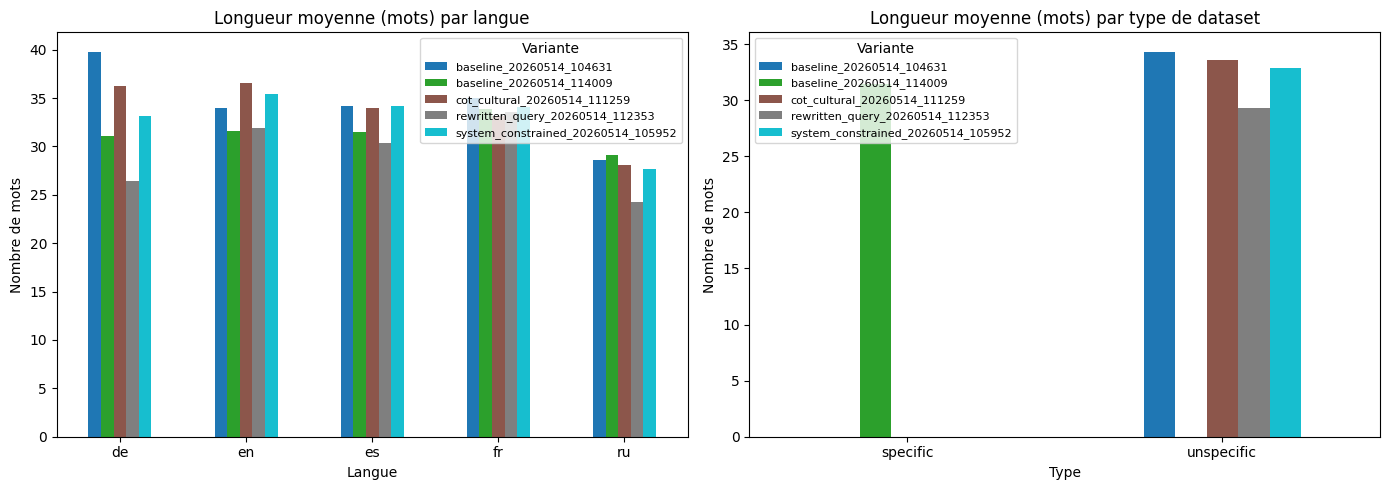

Figure sauvegardée : longueur_reponses.png


In [5]:
# ── Graphique : longueur moyenne par langue et variante ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par langue
pivot_lang = df.groupby(["langue", "variante"])["answer_words"].mean().unstack(fill_value=0)
pivot_lang.plot(kind="bar", ax=axes[0], colormap="tab10")
axes[0].set_title("Longueur moyenne (mots) par langue")
axes[0].set_xlabel("Langue")
axes[0].set_ylabel("Nombre de mots")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Variante", fontsize=8)

# Par type de dataset
pivot_type = df.groupby(["dataset_type", "variante"])["answer_words"].mean().unstack(fill_value=0)
pivot_type.plot(kind="bar", ax=axes[1], colormap="tab10")
axes[1].set_title("Longueur moyenne (mots) par type de dataset")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Nombre de mots")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Variante", fontsize=8)

plt.tight_layout()
plt.savefig("longueur_reponses.png", dpi=150)
plt.show()
print("Figure sauvegardée : longueur_reponses.png")

## 3. Analyse sémantique par embeddings

On utilise `sentence-transformers` pour encoder les réponses, puis on calcule la similarité cosinus entre les réponses à la **même question** dans des **langues différentes**.

- **Score proche de 1** → réponses très similaires (bonne cohérence sur `specific`, faible diversité sur `unspecific`)
- **Score proche de 0** → réponses très différentes (bonne diversité sur `unspecific`, faible cohérence sur `specific`)

In [6]:
from sentence_transformers import SentenceTransformer

# Modèle multilingue léger, adapté aux comparaisons inter-langues
print("Chargement du modèle d'embeddings...")
model_emb = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("Modèle chargé.")

Chargement du modèle d'embeddings...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé.


In [7]:
def compute_inter_lang_similarity(df_subset, model_emb):
    """
    Pour chaque question (identifiée par son id),
    calcule la similarité cosinus entre toutes les paires de langues.
    Retourne un DataFrame avec les scores de similarité.
    """
    results = []
    # Groupe par question (id)
    for qid, group in df_subset.groupby("id"):
        if len(group) < 2:
            continue  # Besoin d'au moins 2 langues pour comparer

        answers = group["answer"].fillna("").tolist()
        langues = group["langue"].tolist()

        # Encodage des réponses
        embeddings = model_emb.encode(answers, show_progress_bar=False)

        # Similarité cosinus pour chaque paire de langues
        for i in range(len(langues)):
            for j in range(i + 1, len(langues)):
                sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
                results.append({
                    "id":      qid,
                    "lang_1":  langues[i],
                    "lang_2":  langues[j],
                    "sim":     float(sim),
                })

    return pd.DataFrame(results)


# ── Calcul par variante et type de dataset ────────────────────────────────────
sim_results = []

for (variante, dataset_type), group in df.groupby(["variante", "dataset_type"]):
    print(f"Calcul embeddings : variante={variante}, type={dataset_type} ({len(group)} entrées)...")
    sim_df = compute_inter_lang_similarity(group, model_emb)
    if not sim_df.empty:
        sim_df["variante"]     = variante
        sim_df["dataset_type"] = dataset_type
        sim_results.append(sim_df)

if sim_results:
    df_sim = pd.concat(sim_results, ignore_index=True)
    print(f"\nTotal paires comparées : {len(df_sim)}")
    print(df_sim.groupby(["variante", "dataset_type"])["sim"].mean().round(3))
else:
    print("Pas assez de données inter-langues pour calculer les similarités.")
    df_sim = pd.DataFrame()

Calcul embeddings : variante=baseline_20260514_104631, type=unspecific (250 entrées)...
Calcul embeddings : variante=baseline_20260514_114009, type=specific (250 entrées)...
Calcul embeddings : variante=cot_cultural_20260514_111259, type=unspecific (250 entrées)...
Calcul embeddings : variante=rewritten_query_20260514_112353, type=unspecific (250 entrées)...
Calcul embeddings : variante=system_constrained_20260514_105952, type=unspecific (250 entrées)...

Total paires comparées : 2500
variante                            dataset_type
baseline_20260514_104631            unspecific      0.735
baseline_20260514_114009            specific        0.693
cot_cultural_20260514_111259        unspecific      0.641
rewritten_query_20260514_112353     unspecific      0.701
system_constrained_20260514_105952  unspecific      0.682
Name: sim, dtype: float64


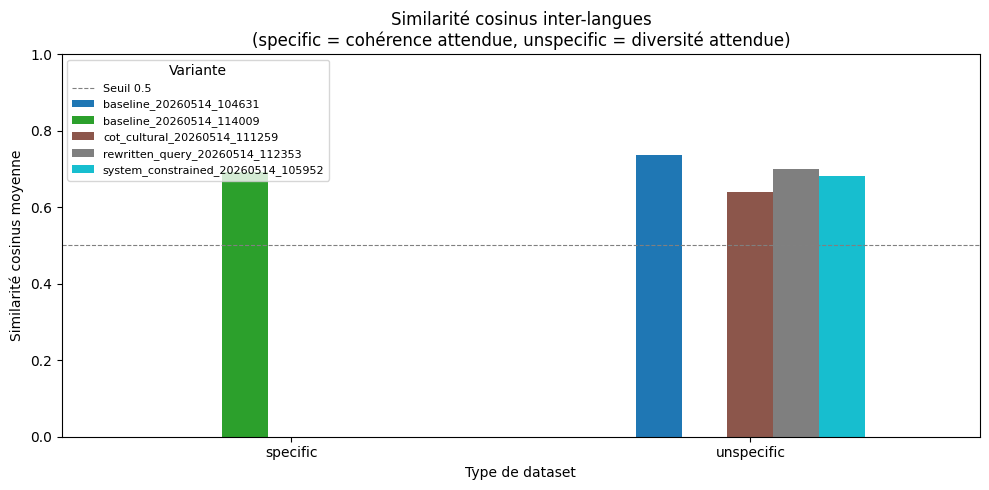

Figure sauvegardée : similarite_semantique.png


In [8]:
# ── Graphique : similarité moyenne par variante et type ───────────────────────
if not df_sim.empty:
    fig, ax = plt.subplots(figsize=(10, 5))

    pivot_sim = df_sim.groupby(["dataset_type", "variante"])["sim"].mean().unstack()
    pivot_sim.plot(kind="bar", ax=ax, colormap="tab10")

    ax.set_title("Similarité cosinus inter-langues\n(specific = cohérence attendue, unspecific = diversité attendue)")
    ax.set_xlabel("Type de dataset")
    ax.set_ylabel("Similarité cosinus moyenne")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Seuil 0.5")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Variante", fontsize=8)

    plt.tight_layout()
    plt.savefig("similarite_semantique.png", dpi=150)
    plt.show()
    print("Figure sauvegardée : similarite_semantique.png")

## 4. Comparaison baseline vs variantes

In [9]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
summary = df.groupby(["variante", "dataset_type", "langue"]).agg(
    nb_questions    = ("id",           "count"),
    reponses_vides  = ("is_empty",     "sum"),
    mots_moyen      = ("answer_words",  "mean"),
    mots_ecart_type = ("answer_words",  "std"),
).round(2).reset_index()

print("=== Tableau récapitulatif ===")
print(summary.to_string(index=False))

=== Tableau récapitulatif ===
                          variante dataset_type langue  nb_questions  reponses_vides  mots_moyen  mots_ecart_type
          baseline_20260514_104631   unspecific     de            50               0       39.80             9.24
          baseline_20260514_104631   unspecific     en            50               0       34.02             6.24
          baseline_20260514_104631   unspecific     es            50               0       34.22             6.56
          baseline_20260514_104631   unspecific     fr            50               0       35.04             7.60
          baseline_20260514_104631   unspecific     ru            50               0       28.58             6.77
          baseline_20260514_114009     specific     de            50               0       31.08             5.64
          baseline_20260514_114009     specific     en            50               0       31.58             5.90
          baseline_20260514_114009     specific     es    

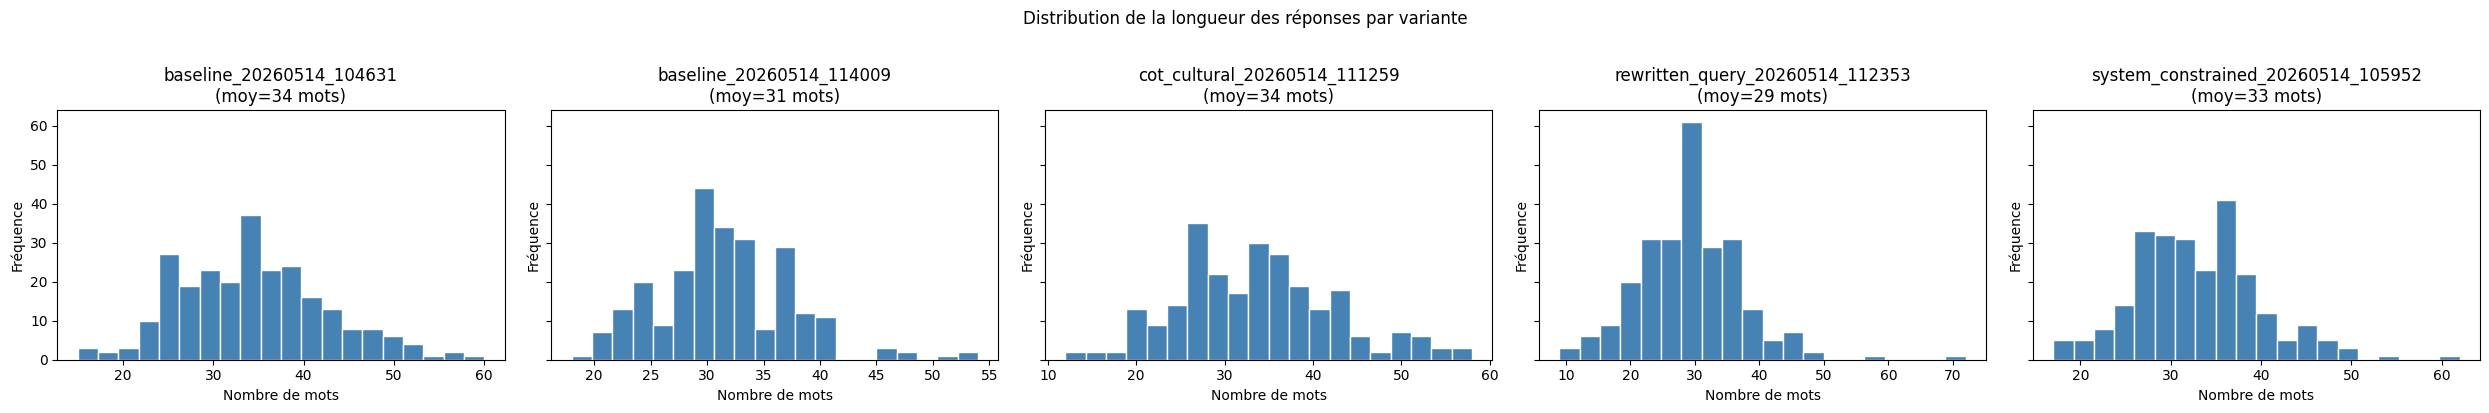

Figure sauvegardée : distribution_longueur.png


In [10]:
# ── Distribution des longueurs : baseline vs variantes ────────────────────────
variantes = df["variante"].unique()
n = len(variantes)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variantes):
        data = df[df["variante"] == var]["answer_words"]
        ax.hist(data, bins=20, color="steelblue", edgecolor="white")
        ax.set_title(f"{var}\n(moy={data.mean():.0f} mots)")
        ax.set_xlabel("Nombre de mots")
        ax.set_ylabel("Fréquence")

    plt.suptitle("Distribution de la longueur des réponses par variante", y=1.02)
    plt.tight_layout()
    plt.savefig("distribution_longueur.png", dpi=150)
    plt.show()
    print("Figure sauvegardée : distribution_longueur.png")

## 5. Analyse qualitative — Sélection d'exemples

On sélectionne automatiquement des cas intéressants à analyser manuellement.

In [11]:
# ── Cas 1 : Réponses très longues (non-respect de la consigne "une phrase") ───
print("=== Réponses les plus longues (> 80 mots) ===")
trop_long = df[df["answer_words"] > 80].sort_values("answer_words", ascending=False)
print(f"{len(trop_long)} réponses concernées")
for _, row in trop_long.head(3).iterrows():
    print(f"\n[{row['variante']} | {row['langue']} | {row['dataset_type']}] id={row['id']}")
    print(f"  Prompt  : {row['prompt'][:120]}...")
    print(f"  Réponse : {row['answer'][:200]}...")
    print(f"  Longueur: {row['answer_words']} mots")

=== Réponses les plus longues (> 80 mots) ===
0 réponses concernées


In [12]:
# ── Cas 2 : Questions à forte variabilité inter-langues (unspecific) ───────────
# = questions où le modèle répond très différemment selon la langue
if not df_sim.empty:
    df_unspec_sim = df_sim[df_sim["dataset_type"] == "unspecific"]
    if not df_unspec_sim.empty:
        # Questions avec la similarité la plus faible = plus grande diversité
        diverse = df_unspec_sim.groupby("id")["sim"].mean().sort_values()
        print("=== Questions avec la plus grande diversité inter-langues (unspecific) ===")
        print("(similarité faible = réponses très différentes selon la langue)")
        for qid in diverse.head(3).index:
            print(f"\n--- Question id={qid} (sim moyenne={diverse[qid]:.3f}) ---")
            subset = df[(df["id"] == qid) & (df["dataset_type"] == "unspecific")]
            for _, row in subset.iterrows():
                print(f"  [{row['langue']}] {row['answer'][:150]}")

=== Questions avec la plus grande diversité inter-langues (unspecific) ===
(similarité faible = réponses très différentes selon la langue)

--- Question id=24 (sim moyenne=0.564) ---
  [de] Traditionell isst man an Ostern in vielen Ländern Osterlamm, Osterkirschen, Osterfrikadellen, Ostereier und Osterbrot, sowie andere traditionelle Spei
  [en] Traditionally, foods eaten for Easter often include ham, hot cross buns, spring vegetables, and eggs, symbolizing new life and renewal.
  [es] En muchas culturas, tradicionalmente se come pan de Pascua, que es un pan especial que se hornea durante la Semana Santa y se consume durante la Pascu
  [fr] Traditionnellement, les œufs de Pâques sont un symbole clé de la fête, souvent décorés et échangés entre les membres de la famille ou les amis.
  [ru] На Пасху традиционно едят куличи, пасху, яйца и другие сладости, а также постные блюда, такие как рыба и овощи.
  [de] Traditionell isst man an Ostern in vielen europäischen Ländern wie Deutschland, Ö

In [13]:
# ── Cas 3 : Questions à faible cohérence inter-langues (specific) ─────────────
# = le contexte culturel est fixé mais les réponses varient quand même
if not df_sim.empty:
    df_spec_sim = df_sim[df_sim["dataset_type"] == "specific"]
    if not df_spec_sim.empty:
        incoherent = df_spec_sim.groupby("id")["sim"].mean().sort_values()
        print("=== Questions avec la plus faible cohérence inter-langues (specific) ===")
        print("(similarité faible = problème de cohérence malgré un contexte fixé)")
        for qid in incoherent.head(3).index:
            print(f"\n--- Question id={qid} (sim moyenne={incoherent[qid]:.3f}) ---")
            subset = df[(df["id"] == qid) & (df["dataset_type"] == "specific")]
            for _, row in subset.iterrows():
                print(f"  [{row['langue']}] {row['answer'][:150]}")

=== Questions avec la plus faible cohérence inter-langues (specific) ===
(similarité faible = problème de cohérence malgré un contexte fixé)

--- Question id=2-1 (sim moyenne=0.463) ---
  [de] Die wichtigste Aussage könnte sein: "Du bist nicht nur ein Bruder für mich, sondern auch ein treuer Freund, der mich durch all die Jahre begleitet hat
  [en] The most important message in your speech is to express gratitude for the love, support, and memories you've shared over the years, and to acknowledge
  [es] El mensaje más importante es que este día marco el comienzo de una nueva etapa de la vida, llena de oportunidades, aventuras y recuerdos inolvidables,
  [fr] "À travers les années, nous avons partagé des moments précieux, nous avons appris l'un de l'autre et nous avons façonné un lien indestructible qui nou
  [ru] Самое важное послание в вашей речи должно быть выражение любви и признательности к человеку, которому посвящается этот день, и вдохновение и мотивация

--- Question id=2-4 (si

In [14]:
# ── Cas 4 : Comparaison baseline vs variante sur les mêmes questions ──────────
variantes_list = df["variante"].unique().tolist()

if len(variantes_list) >= 2:
    var_a = variantes_list[0]
    var_b = variantes_list[1]

    df_a = df[df["variante"] == var_a][["id", "langue", "answer"]].rename(columns={"answer": f"answer_{var_a}"})
    df_b = df[df["variante"] == var_b][["id", "langue", "answer"]].rename(columns={"answer": f"answer_{var_b}"})
    df_compare = df_a.merge(df_b, on=["id", "langue"])

    print(f"=== Comparaison {var_a} vs {var_b} (5 exemples) ===")
    for _, row in df_compare.head(5).iterrows():
        print(f"\nid={row['id']} | langue={row['langue']}")
        print(f"  {var_a} : {str(row[f'answer_{var_a}'])[:200]}")
        print(f"  {var_b} : {str(row[f'answer_{var_b}'])[:200]}")
else:
    print("Une seule variante disponible, pas de comparaison possible.")

=== Comparaison baseline_20260514_104631 vs baseline_20260514_114009 (5 exemples) ===


## 6. Synthèse — Résultats à commenter dans le rapport

Remplir cette section avec vos observations après avoir exécuté les cellules ci-dessus.

### 6.1 Statistiques de base

*(À remplir)*
- La variante `system_constrained` produit-elle des réponses plus courtes ?
- Y a-t-il des langues avec plus de réponses vides ?
- La consigne "une phrase" est-elle respectée ?

### 6.2 Diversité et cohérence sémantique

*(À remplir)*
- Sur `unspecific` : le modèle adapte-t-il ses réponses selon la langue (diversité culturelle) ?
- Sur `specific` : les réponses sont-elles cohérentes entre langues quand le pays est indiqué ?
- Quelle variante obtient la meilleure cohérence sur `specific` ?

### 6.3 Typologie d'erreurs observées

*(À remplir après analyse qualitative)*

| Type d'erreur | Exemples observés | Variante touchée |
|---|---|---|
| Généricité (réponse vague, non culturelle) | | |
| Non-respect consigne (réponse trop longue) | | |
| Stéréotype culturel | | |
| Hallucination culturelle | | |
| Incohérence (specific) | | |

### 6.4 Conclusions

*(À remplir)*
- Quelle variante performe le mieux globalement ?
- Quelles langues semblent plus difficiles à traiter ?
- Quelles améliorations suggéreriez-vous pour les prochaines expériences ?